In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [11]:
sber = pd.read_csv('data/SBRF.txt')

In [12]:
def good_dataframe(data):
  data.drop(['<TICKER>', '<PER>'], inplace=True, axis=1)
  data.columns = ['date', 'time', 'open', 'high', 'low', 'close', 'volume']
  data['date'] = pd.to_datetime(data['date'], format='%Y%m%d')
  data['time'] = pd.to_datetime(data['time'], format='%H%M%S')
  data['time'] = data['time'].dt.time
  data['time'] = pd.to_datetime(data['date'].astype('str') + ' '+ data['time'].astype('str'))
  data.drop(['date'], inplace=True, axis=1)
  data = data.set_index('time')
  data_copy = data.copy()
  return data, data_copy



In [13]:
sber_df_1m, sber_df__1m_copy = good_dataframe(sber)

In [14]:
sber_df_1m

,open,high,low,close,volume
time,,,,,
2009-01-11 10:30:00,2301,2335,2301,2321,123
2009-01-11 10:31:00,2321,2321,2265,2269,194
2009-01-11 10:32:00,2310,2344,2310,2344,383
2009-01-11 10:33:00,2344,2346,2333,2333,67
2009-01-11 10:34:00,2334,2334,2334,2334,2
...,...,...,...,...,...
2025-06-30 23:44:00,29851,29851,29845,29845,28
2025-06-30 23:45:00,29843,29845,29829,29845,39
2025-06-30 23:47:00,29828,29828,29827,29827,3


Text(0, 0.5, 'Цена закрытия')

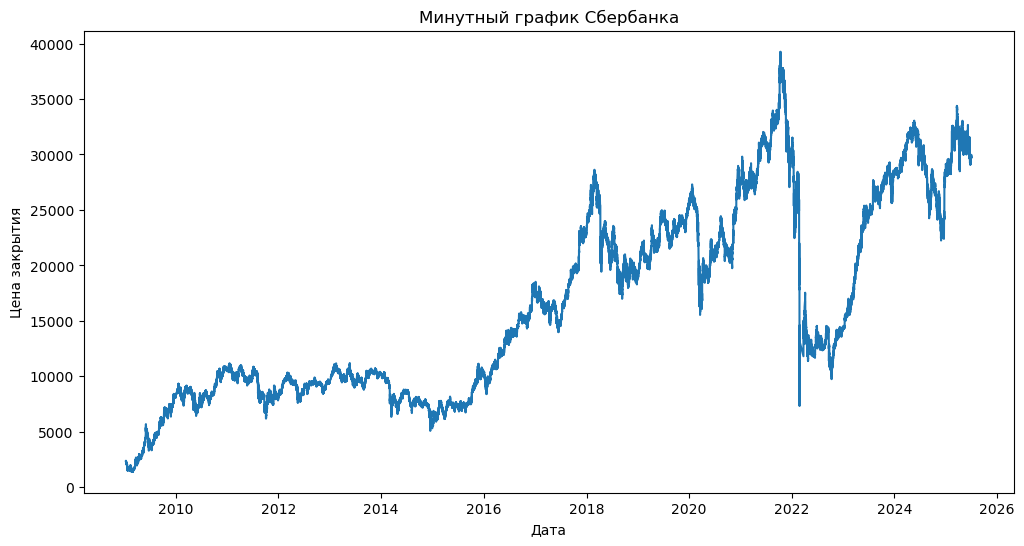

In [15]:
fig = plt.figure(figsize=(12, 6))
Lineplot = sns.lineplot(
    data=sber_df_1m,
    x='time',
    y='close'
)
Lineplot.set_title('Минутный график Сбербанка')
Lineplot.set_xlabel('Дата')
Lineplot.set_ylabel('Цена закрытия')

Создадим из минутного графика другие таймфреймы

In [16]:
def new_timeframe(data, timeframe):
  if timeframe == '5 min':
    data_5m = data.resample('5min').agg({'open' : 'first', 'high' : 'max', 'low' : 'min', 'close' : 'last', 'volume' : 'sum'}).dropna()
    return data_5m
  elif timeframe == '15 min':
    data_15m = data.resample('15min').agg({'open' : 'first', 'high' : 'max', 'low' : 'min', 'close' : 'last', 'volume' : 'sum'}).dropna()
    return data_15m
  elif timeframe == '30 min':
    data_30m = data.resample('30min').agg({'open' : 'first', 'high' : 'max', 'low' : 'min', 'close' : 'last', 'volume' : 'sum'}).dropna()
    return data_30m

  elif timeframe == '1h':
    data_1H = data.resample('1h').agg({'open' : 'first', 'high' : 'max', 'low' : 'min', 'close' : 'last', 'volume' : 'sum'}).dropna()
    return data_1H
  elif timeframe == '2h':
    data_2H = data.resample('2h').agg({'open' : 'first', 'high' : 'max', 'low' : 'min', 'close' : 'last', 'volume' : 'sum'}).dropna()
    return data_2H
  elif timeframe == '4h':
    data_4H = data.resample('4h').agg({'open' : 'first', 'high' : 'max', 'low' : 'min', 'close' : 'last', 'volume' : 'sum'}).dropna()
    return data_4H

  elif timeframe == 'D':
    data_D = data.resample('D').agg({'open' : 'first', 'high' : 'max', 'low' : 'min', 'close' : 'last', 'volume' : 'sum'}).dropna()
    return data_D


In [17]:
sber_4H = new_timeframe(sber_df_1m, '4h')
sber_4H

,open,high,low,close,volume
time,,,,,
2009-01-11 08:00:00,2301.0,2380.0,2265.0,2346.0,13466
2009-01-11 12:00:00,2346.0,2354.0,2319.0,2320.0,5528
2009-01-11 16:00:00,2321.0,2358.0,2319.0,2343.0,6260
2009-01-11 20:00:00,2343.0,2359.0,2335.0,2353.0,1250
2009-01-12 08:00:00,2345.0,2353.0,2323.0,2333.0,10626
...,...,...,...,...,...
2025-06-27 20:00:00,29733.0,29745.0,29651.0,29686.0,6944
2025-06-30 08:00:00,29750.0,29975.0,29679.0,29686.0,71639
2025-06-30 12:00:00,29687.0,29870.0,29646.0,29838.0,40482


Поработаем с новой библиотекой mplfinance, построим пару графиков

In [18]:
import mplfinance as mpf

In [19]:
sber_4H_from_2022 = sber_4H[sber_4H.index > pd.to_datetime('2022-01-01')]

In [20]:
sber_4H_from_2022

,open,high,low,close,volume
time,,,,,
2022-01-03 04:00:00,29890.0,30150.0,29890.0,30037.0,13463
2022-01-03 08:00:00,30040.0,30888.0,30028.0,30661.0,137820
2022-01-03 12:00:00,30660.0,30772.0,30572.0,30720.0,60517
2022-01-03 16:00:00,30729.0,30930.0,30696.0,30844.0,59705
2022-01-03 20:00:00,30838.0,31088.0,30832.0,31058.0,21801
...,...,...,...,...,...
2025-06-27 20:00:00,29733.0,29745.0,29651.0,29686.0,6944
2025-06-30 08:00:00,29750.0,29975.0,29679.0,29686.0,71639
2025-06-30 12:00:00,29687.0,29870.0,29646.0,29838.0,40482


c:\Users\user\anaconda3\Lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


<Figure size 1200x600 with 0 Axes>

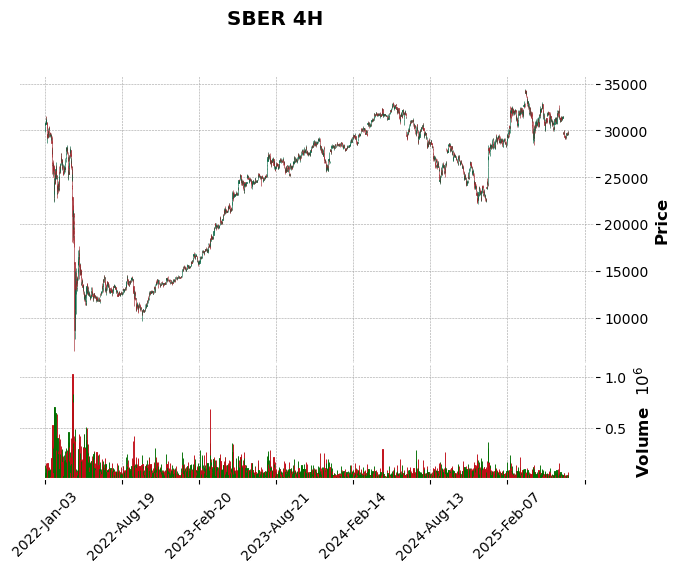

In [21]:
fig = plt.figure(figsize=(12, 6))
mpf.plot(
    data = sber_4H_from_2022,
    type='candle',
    style='charles',
    title='SBER 4H',
    volume=True,

);

In [22]:
sber_4H_from_2022['SMA_10'] = sber_4H_from_2022['close'].rolling(window=10).mean()
sber_4H_from_2022['EMA_10'] = sber_4H_from_2022['close'].ewm(span=10, adjust=False).mean()

C:\Users\user\AppData\Local\Temp\ipykernel_13504\383882004.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sber_4H_from_2022['SMA_10'] = sber_4H_from_2022['close'].rolling(window=10).mean()
C:\Users\user\AppData\Local\Temp\ipykernel_13504\383882004.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sber_4H_from_2022['EMA_10'] = sber_4H_from_2022['close'].ewm(span=10, adjust=False).mean()


In [23]:
sber_4H_from_2022

,open,high,low,close,volume,SMA_10,EMA_10
time,,,,,,,
2022-01-03 04:00:00,29890.0,30150.0,29890.0,30037.0,13463,NaN,30037.000000
2022-01-03 08:00:00,30040.0,30888.0,30028.0,30661.0,137820,NaN,30150.454545
2022-01-03 12:00:00,30660.0,30772.0,30572.0,30720.0,60517,NaN,30254.008264
2022-01-03 16:00:00,30729.0,30930.0,30696.0,30844.0,59705,NaN,30361.279489
2022-01-03 20:00:00,30838.0,31088.0,30832.0,31058.0,21801,NaN,30487.955946
...,...,...,...,...,...,...,...
2025-06-27 20:00:00,29733.0,29745.0,29651.0,29686.0,6944,29612.3,29599.869672
2025-06-30 08:00:00,29750.0,29975.0,29679.0,29686.0,71639,29611.6,29615.529731
2025-06-30 12:00:00,29687.0,29870.0,29646.0,29838.0,40482,29626.0,29655.978871


Посмторим на волатильность Сбербанка

In [24]:
sber_1H = new_timeframe(sber_df_1m, '1h')

In [25]:
sber_1H

,open,high,low,close,volume
time,,,,,
2009-01-11 10:00:00,2301.0,2380.0,2265.0,2361.0,7797
2009-01-11 11:00:00,2366.0,2369.0,2324.0,2346.0,5669
2009-01-11 12:00:00,2346.0,2354.0,2328.0,2339.0,2264
2009-01-11 13:00:00,2335.0,2346.0,2330.0,2338.0,876
2009-01-11 14:00:00,2339.0,2342.0,2333.0,2334.0,860
...,...,...,...,...,...
2025-06-30 19:00:00,29871.0,29892.0,29830.0,29859.0,1093
2025-06-30 20:00:00,29858.0,29879.0,29847.0,29857.0,756
2025-06-30 21:00:00,29857.0,29876.0,29854.0,29865.0,1059


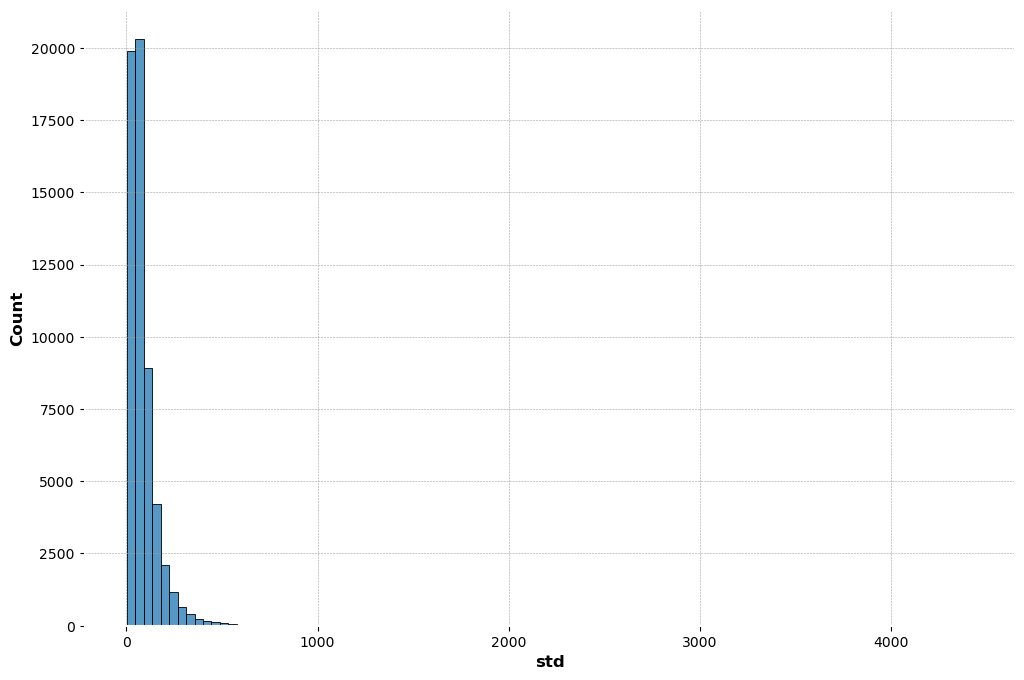

In [26]:
sber_1H['std'] = sber_1H['close'].rolling(10).std()
fig = plt.figure(figsize=(12, 8))
Histplot = sns.histplot(
    data=sber_1H,
    x='std',
    bins=100)


Поработаем с индикатором RSI

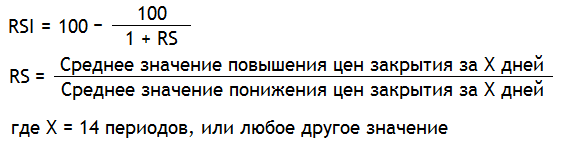

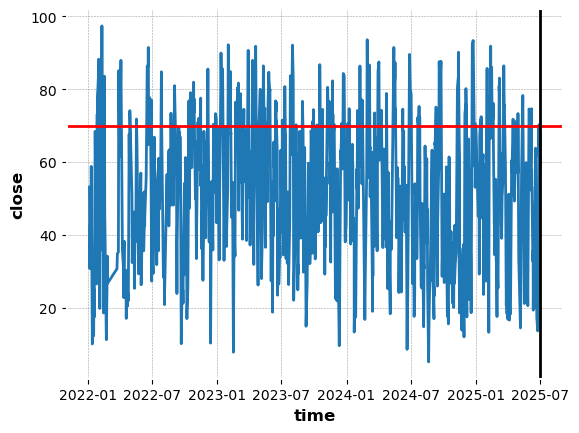

In [27]:
window = 14
close_prices = sber_4H_from_2022['close']
delta = close_prices.diff(1)

gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(window=window).mean()
avg_loss = loss.rolling(window=window).mean()

rs = avg_gain / avg_loss

rsi = 100 - (100 / (1 + rs))
Lineplot = sns.lineplot(
    data=rsi
)
target_date = pd.to_datetime('2025-06-30 08:00:00')
Lineplot.axhline(y=70, color='red')
Lineplot.axvline(x=target_date, color='black')

#Напишем несколько проектов.#

1. Загрузка 2 активов с помощью библиотеки yfinance

Справочный материал

In [28]:
# import yfinance as yf
# data = yf.download(
#     tickers="AAPL",       # Тикер акции
#     period="1y",          # Период: 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max
#     interval="1d",        # Интервал: 1m, 2m, 5m, 15m, 30m, 60m, 90m, 1h, 1d, 5d, 1wk, 1mo, 3mo
#     start="2023-01-01",   # Начальная дата (альтернатива period)
#     end="2023-12-31",     # Конечная дата (альтернатива period)
#     prepost=False,        # Включать пре/пост-рыночные данные
#     repair=True           # Автокоррекция ошибок в данных
# )

In [31]:
import yfinance as yf
apple = yf.download(
    tickers='AAPL',
    period='1y',
    interval='1d',
)

C:\Users\user\AppData\Local\Temp\ipykernel_13504\4294288942.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  apple = yf.download(
[*********************100%***********************]  1 of 1 completed


In [32]:
# Преобразование мультииндекса
def flatten_multiindex(df):
    df.columns = ['_'.join(col).strip() for col in df.columns.values]
    return df

apple_df = flatten_multiindex(apple)
apple_df

,Close_AAPL,High_AAPL,Low_AAPL,Open_AAPL,Volume_AAPL
Date,,,,,
2024-07-23,223.962585,225.883609,221.643430,223.325565,39960300
2024-07-24,217.522705,223.753575,216.119280,222.957296,61777600
2024-07-25,216.477631,219.821991,213.620980,217.910915,51391200
2024-07-26,216.945419,218.468296,215.004484,217.681965,41601300
2024-07-29,217.224121,218.279184,214.745706,215.950081,36311800
...,...,...,...,...,...
2025-07-16,210.160004,212.399994,208.639999,210.300003,47490500
2025-07-17,210.020004,211.800003,209.589996,210.570007,48068100
2025-07-18,211.179993,211.789993,209.699997,210.869995,48974600


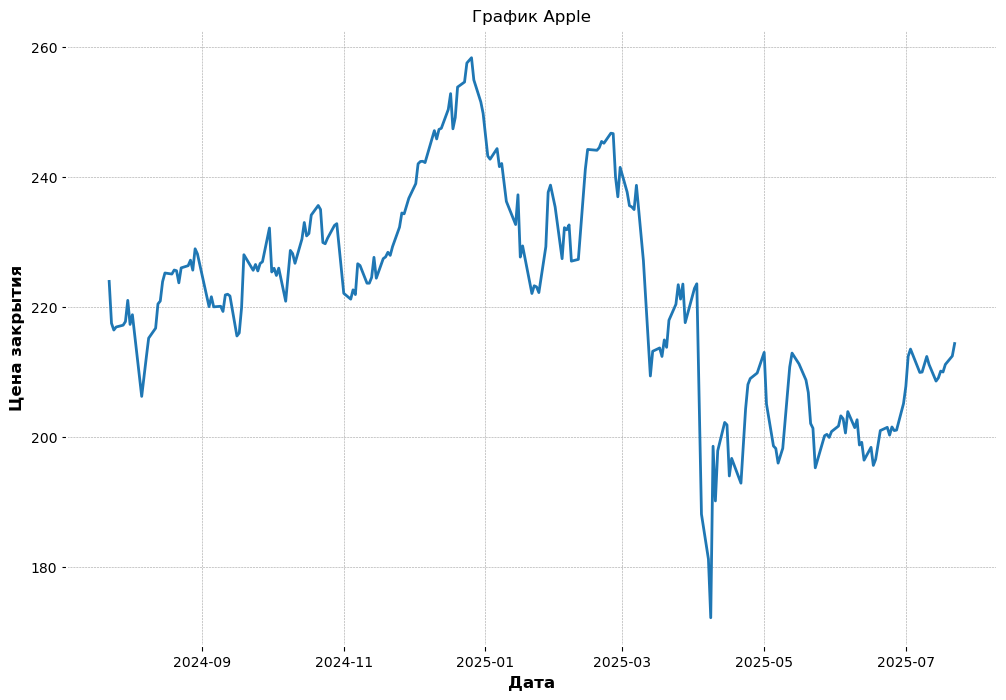

In [33]:
fig = plt.figure(figsize=(12, 8))
Lineplot = sns.lineplot(
    data=apple_df,
    x=apple_df.index,
    y='Close_AAPL')
Lineplot.set_title('График Apple')
Lineplot.set_ylabel('Цена закрытия')
Lineplot.set_xlabel('Дата');

In [34]:
BTC = yf.download(tickers='BTC-USD',
                  period='1y',
                  interval='1d')

C:\Users\user\AppData\Local\Temp\ipykernel_13504\3674893536.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  BTC = yf.download(tickers='BTC-USD',
[*********************100%***********************]  1 of 1 completed


In [35]:
def flatten_multiindex(df):
    df.columns = ['_'.join(col).strip() for col in df.columns.values]
    return df

BTC_df = flatten_multiindex(BTC)
BTC_df.columns = ['close', 'high', 'low', 'open', 'volume']

<Figure size 1200x600 with 0 Axes>

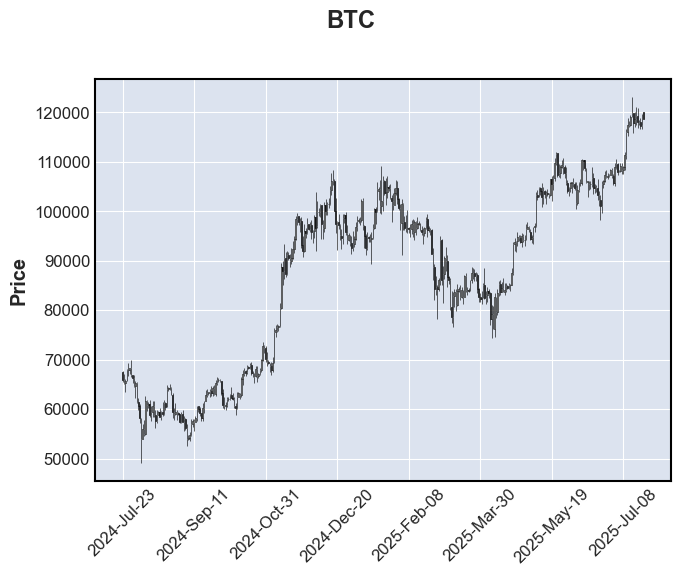

In [36]:

fig = plt.figure(figsize=(12, 6))
mpf.plot(
    data=BTC_df,
    type='candle',
    title='BTC'
)

2. На 2 месячном графике показать 2 скользящих средних(любых) и закрасить между ними область(либо красным, либо зеленым)

In [37]:
sber_4H_2month = sber_4H[(sber_4H.index > pd.to_datetime('2023-01-01')) & (sber_4H.index < pd.to_datetime('2023-03-01'))]
sber_4H_2month

,open,high,low,close,volume
time,,,,,
2023-01-03 08:00:00,14380.0,14583.0,14380.0,14480.0,56518
2023-01-03 12:00:00,14480.0,14480.0,14350.0,14422.0,37569
2023-01-03 16:00:00,14422.0,14424.0,14361.0,14393.0,20265
2023-01-03 20:00:00,14396.0,14425.0,14388.0,14406.0,5646
2023-01-04 08:00:00,14392.0,14450.0,14307.0,14351.0,41225
...,...,...,...,...,...
2023-02-27 20:00:00,17023.0,17099.0,17008.0,17081.0,18730
2023-02-28 08:00:00,17081.0,17270.0,16989.0,17106.0,231348
2023-02-28 12:00:00,17105.0,17105.0,16905.0,17017.0,105776


In [38]:
sber_4H_2month['SMA_30'] = sber_4H_2month['close'].rolling(30).mean()
sber_4H_2month['SMA_10'] = sber_4H_2month['close'].rolling(10).mean()

C:\Users\user\AppData\Local\Temp\ipykernel_13504\3952929205.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sber_4H_2month['SMA_30'] = sber_4H_2month['close'].rolling(30).mean()
C:\Users\user\AppData\Local\Temp\ipykernel_13504\3952929205.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sber_4H_2month['SMA_10'] = sber_4H_2month['close'].rolling(10).mean()


Text(0, 0.5, 'Цена закрытия')

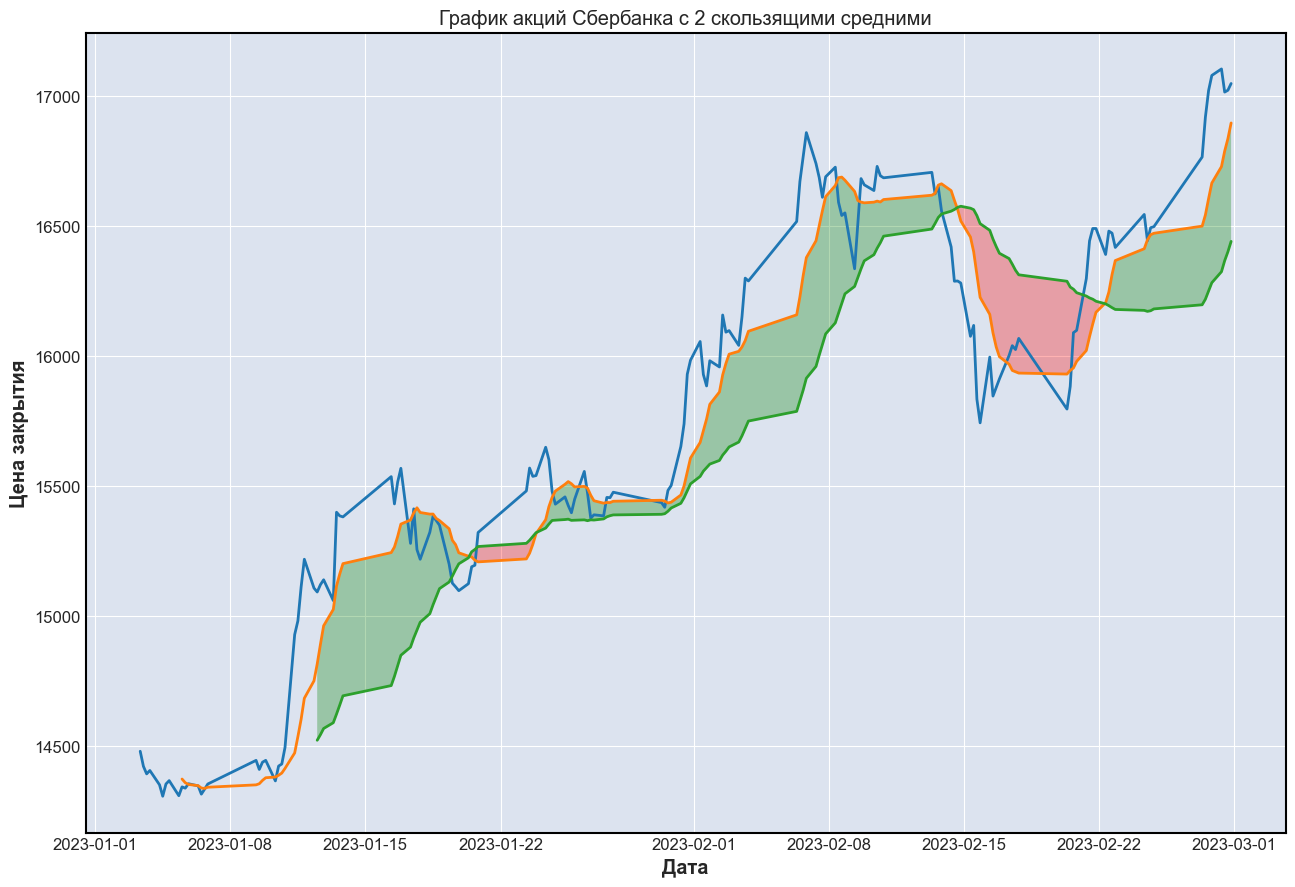

In [39]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_axes([0, 0, 1, 1])
sns.lineplot(data=sber_4H_2month, y='close', x=sber_4H_2month.index, ax=ax)
sns.lineplot(data=sber_4H_2month, y='SMA_10', x=sber_4H_2month.index, ax=ax)
sns.lineplot(data=sber_4H_2month, y='SMA_30', x=sber_4H_2month.index, ax=ax)

ax.fill_between(x=sber_4H_2month.index,
                y1=sber_4H_2month['SMA_30'],
                y2=sber_4H_2month['SMA_10'],
                where=sber_4H_2month['SMA_10'] < sber_4H_2month['SMA_30'],
                facecolor='red',
                alpha=0.3,
                interpolate=True)

ax.fill_between(x=sber_4H_2month.index,
                y1=sber_4H_2month['SMA_30'],
                y2=sber_4H_2month['SMA_10'],
                where=sber_4H_2month['SMA_10'] >= sber_4H_2month['SMA_30'],
                facecolor='green',
                alpha=0.3,
                interpolate=True)
ax.set_title('График акций Сбербанка с 2 скользящими средними')
ax.set_xlabel('Дата')
ax.set_ylabel('Цена закрытия')